# ListingIQ

## Overview

ListingIQ is a composite quality metric designed to evaluate the overall quality and desirability of an Airbnb listing.

ListingIQ focuses exclusively on the characteristics of the property itself. The score is constructed by evaluating multiple listing attributes, validating their relationship with guest satisfaction, and combining the selected variables into a weighted composite score.

The final ListingIQ ranges from 0 to 100, where higher scores represent higher-quality listings.

### Candidate Variables
| Variable          | Description                                                    |
| ----------------- | -------------------------------------------------------------- |
| **Property Type** | Type of property being offered (Apartment, House, Villa, etc.) |
| **Room Type**     | Level of privacy offered to guests                             |
| **Accommodates**  | Maximum number of guests the property can host                 |
| **Bedrooms**      | Number of bedrooms available                                   |
| **Amenities**     | Quantity and variety of amenities provided                     |


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

In [2]:
listings_clean = pd.read_csv(
    "../../../Data/cleaned/Listings_Clean.csv",
    encoding="latin1"
)
listings_fe = listings_clean.copy()

In [3]:
listings_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279599 entries, 0 to 279598
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279599 non-null  int64  
 1   name                         279424 non-null  object 
 2   host_id                      279599 non-null  int64  
 3   host_since                   279434 non-null  object 
 4   host_location                278759 non-null  object 
 5   host_response_time           150898 non-null  object 
 6   host_response_rate           150898 non-null  float64
 7   host_acceptance_rate         166577 non-null  float64
 8   host_is_superhost            279434 non-null  object 
 9   host_total_listings_count    279434 non-null  float64
 10  host_has_profile_pic         279434 non-null  object 
 11  host_identity_verified       279434 non-null  object 
 12  neighbourhood                279599 non-null  object 
 13 

## Validation 1: Property Type

Property Type represents the type of accommodation being offered, such as an apartment, house, condominium, or villa.

Different property types offer varying levels of comfort, privacy, and amenities, which may influence the overall guest experience. This analysis evaluates whether Property Type is associated with guest satisfaction and whether it should contribute to the ListingIQ score.

In [4]:
listings_fe["property_type"].value_counts().head(15)

property_type
Entire apartment                     138989
Private room in apartment             47322
Private room in house                 13292
Entire house                          13273
Entire condominium                    11250
Room in boutique hotel                 5705
Entire loft                            4587
Private room in condominium            4462
Private room in bed and breakfast      4238
Entire serviced apartment              3973
Room in hotel                          3161
Private room in townhouse              2959
Shared room in apartment               2420
Entire townhouse                       2331
Entire guest suite                     2273
Name: count, dtype: int64

In [5]:
property_analysis = (
    listings_fe
    .groupby("property_type")["review_scores_rating"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("count", ascending=False)
)

property_analysis.head(15)

,count,mean,median,std
property_type,,,,
Entire apartment,102621,93.551310,96.0,9.114638
Private room in apartment,28278,93.301825,97.0,11.097932
Entire house,8635,94.655240,98.0,9.525703
Private room in house,8216,93.197298,97.0,11.675972
Entire condominium,7787,94.158855,97.0,8.940383
Entire loft,3785,94.792602,97.0,7.330145
Room in boutique hotel,3034,90.710283,94.0,12.360029
Private room in condominium,2418,93.084781,97.0,12.589960
Entire serviced apartment,2303,92.077725,96.0,12.373901


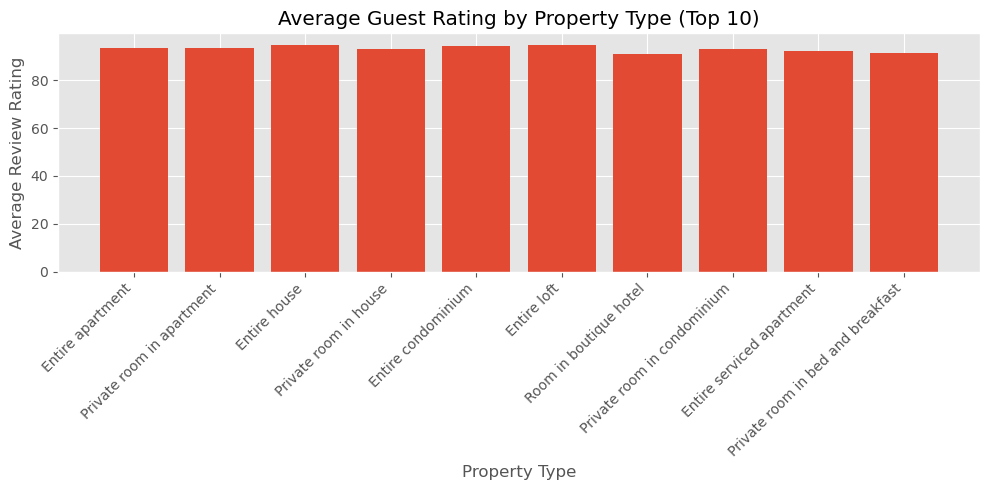

In [6]:
top10 = property_analysis.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10.index,
    top10["mean"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Review Rating")
plt.xlabel("Property Type")
plt.title("Average Guest Rating by Property Type (Top 10)")

plt.tight_layout()
plt.show()

| Variable                        | Property Type |
| ------------------------------- | ------------- |
| Business Relevance              | High          |
| Observed Impact                 | Moderate      |
| Data Reliability                | High          |
| Improvement Potential           | Low           |
| Expected Influence on ListingIQ | Medium        |


## Validation 2: Room Type

Room Type represents the level of privacy provided to guests, distinguishing whether an entire property, a private room, a shared room, or a hotel room is being offered.

Privacy is one of the most important factors influencing the overall guest experience, as entire properties generally provide greater comfort, flexibility, and exclusivity than shared accommodations.

In [7]:
listings_fe["room_type"].value_counts()

room_type
Entire place    182005
Private room     86988
Hotel room        5744
Shared room       4862
Name: count, dtype: int64

In [8]:
room_analysis = (
    listings_fe
    .groupby("room_type")["review_scores_rating"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("count", ascending=False)
)

room_analysis

,count,mean,median,std
room_type,,,,
Entire place,132189,93.735500,96.0,9.177053
Private room,50124,92.836126,97.0,11.750016
Hotel room,3770,90.666578,93.0,11.862079
Shared room,2224,91.240558,96.0,14.138196


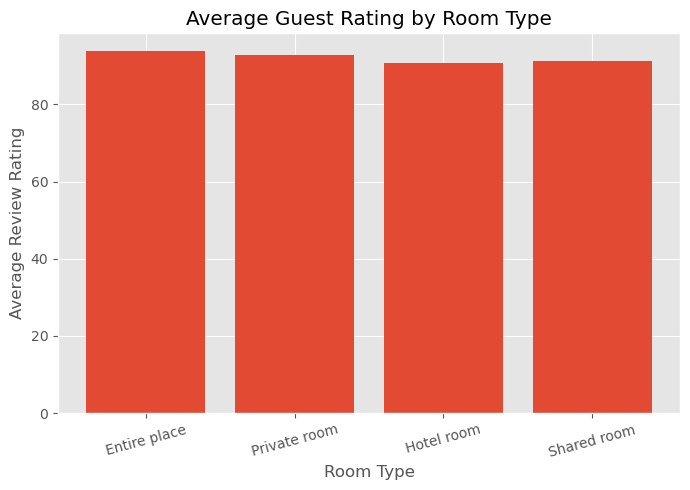

In [9]:
plt.figure(figsize=(7,5))

plt.bar(
    room_analysis.index,
    room_analysis["mean"]
)

plt.title("Average Guest Rating by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Review Rating")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

| Variable                        | Room Type |
| ------------------------------- | --------- |
| Business Relevance              | High      |
| Observed Impact                 | Moderate  |
| Data Reliability                | High      |
| Improvement Potential           | Low       |
| Expected Influence on ListingIQ | Medium    |


## Validation 3: Accommodates

The **Accommodates** variable represents the maximum number of guests a listing can host.

Listings with a higher accommodation capacity generally offer more space and flexibility, making them suitable for larger groups and families. However, increasing capacity does not necessarily translate to a better guest experience. This analysis evaluates whether accommodation capacity is associated with guest satisfaction and whether it should contribute to the ListingIQ score.

In [10]:
listings_fe["accommodates"].describe()

count    279599.000000
mean          3.289733
std           2.133007
min           1.000000
25%           2.000000
50%           2.000000
75%           4.000000
max          16.000000
Name: accommodates, dtype: float64

In [11]:
accommodates_analysis = (
    listings_fe
    .groupby("accommodates")["review_scores_rating"]
    .agg(["count", "mean", "median", "std"])
)

accommodates_analysis

,count,mean,median,std
accommodates,,,,
1,13593,93.006253,97.0,12.112500
2,79727,93.338468,96.0,10.141782
3,19608,93.332772,96.0,9.748204
4,40489,93.576996,96.0,9.516036
5,9728,93.341283,96.0,9.767340
6,13750,93.794109,96.0,9.413309
7,2625,93.809905,96.0,9.355613
8,4344,93.848066,97.0,10.063392
9,798,92.768170,96.0,11.390530


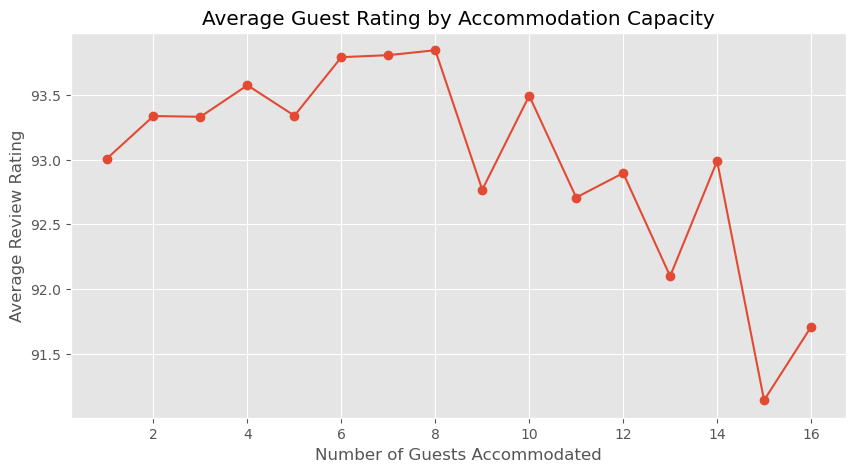

In [12]:
plt.figure(figsize=(10,5))

plt.plot(
    accommodates_analysis.index,
    accommodates_analysis["mean"],
    marker="o"
)

plt.title("Average Guest Rating by Accommodation Capacity")
plt.xlabel("Number of Guests Accommodated")
plt.ylabel("Average Review Rating")

plt.grid(True)
plt.show()

| Variable                        | Accommodates  |
| ------------------------------- | ------------- |
| Business Relevance              | High          |
| Observed Impact                 | Weak–Moderate |
| Data Reliability                | High          |
| Improvement Potential           | Low           |
| Expected Influence on ListingIQ | Medium        |


## Validation 4: Bedrooms

The **Bedrooms** variable represents the number of bedrooms available within a listing.

A greater number of bedrooms generally indicates a larger and more spacious property, making it suitable for families and larger groups.

In [13]:
listings_fe["bedrooms"].describe()

count    250277.000000
mean          1.515509
std           1.153080
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          50.000000
Name: bedrooms, dtype: float64

In [14]:
bedroom_analysis = (
    listings_fe
    .groupby("bedrooms")["review_scores_rating"]
    .agg(["count", "mean", "median", "std"])
)

bedroom_analysis

,count,mean,median,std
bedrooms,,,,
1.0,114184,93.417852,96.0,10.059901
2.0,35781,93.824432,97.0,9.622551
3.0,12452,94.147928,97.0,9.521470
4.0,4086,94.307636,98.0,9.943245
5.0,1213,94.305853,98.0,10.865193
6.0,395,93.225316,97.0,10.880400
7.0,131,92.190840,96.0,11.245590
8.0,64,91.359375,96.0,16.282591
9.0,36,86.583333,95.5,21.086726


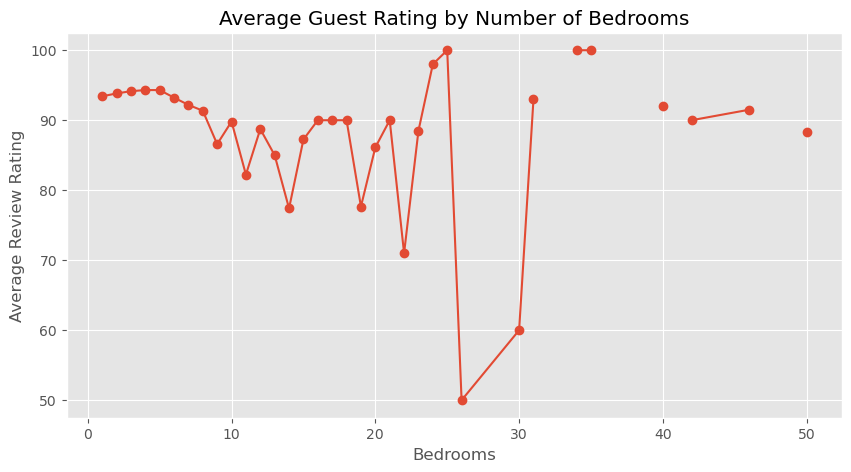

In [15]:
plt.figure(figsize=(10,5))

plt.plot(
    bedroom_analysis.index,
    bedroom_analysis["mean"],
    marker="o"
)

plt.title("Average Guest Rating by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Review Rating")

plt.grid(True)
plt.show()

| Variable                            | Bedrooms                               |
| ----------------------------------- | -------------------------------------- |
| Business Relevance                  | High                                   |
| Observed Impact                     | Moderate                               |
| Data Reliability                    | High (1–5 bedrooms), Low (>5 bedrooms) |
| Improvement Potential               | Low                                    |
| **Expected Influence on ListingIQ** | **Low**                                |


## Validation 5: Amenities

The **Number of Amenities** represents the total count of amenities provided by a listing.

Listings offering a greater number of amenities may provide increased comfort, convenience, and functionality, potentially leading to a better guest experience. This analysis evaluates whether the quantity of amenities is associated with guest satisfaction and whether it should contribute to the ListingIQ score.

In [16]:
listings_fe["amenities"].describe()

count                          279599
unique                         244893
top       ["Long term stays allowed"]
freq                             1386
Name: amenities, dtype: object

In [17]:
import ast

listings_fe["amenities_count"] = listings_fe["amenities"].apply(
    lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0
)

In [18]:
listings_fe[["amenities", "amenities_count"]].head()

,amenities,amenities_count
0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",5
1,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",8
2,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",6
3,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",5
4,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",12


In [19]:
amenities_analysis = (
    listings_fe
    .groupby("amenities_count")["review_scores_rating"]
    .agg(["count", "mean", "median", "std"])
)

amenities_analysis

,count,mean,median,std
amenities_count,,,,
0,25,91.520000,91.0,8.165578
1,303,87.092409,93.0,17.781177
2,108,87.074074,93.5,18.990260
3,201,89.154229,95.0,15.884618
4,399,86.526316,90.0,17.154594
...,...,...,...,...
76,1,100.000000,100.0,NaN
78,1,95.000000,95.0,NaN
81,1,93.000000,93.0,NaN


In [20]:
amenity_limit = listings_fe["amenities_count"].quantile(0.95)

amenity_limit

np.float64(36.0)

In [21]:
amenities_plot = amenities_analysis[
    amenities_analysis.index <= amenity_limit
]

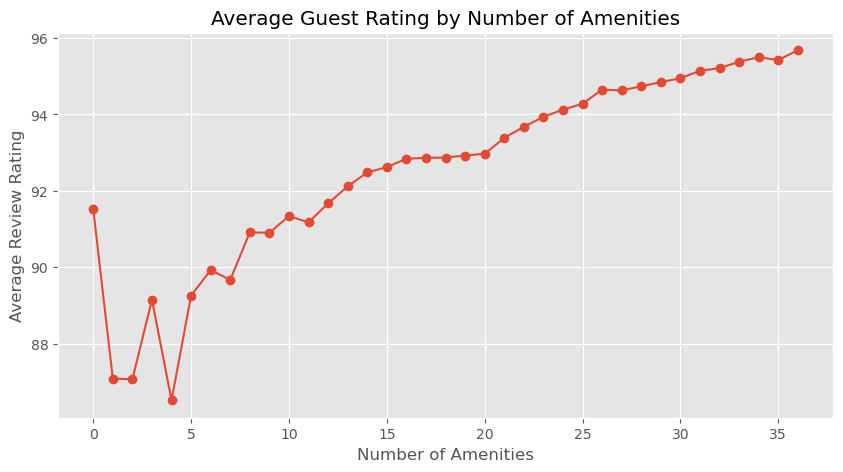

In [22]:
plt.figure(figsize=(10,5))

plt.plot(
    amenities_plot.index,
    amenities_plot["mean"],
    marker="o"
)

plt.title("Average Guest Rating by Number of Amenities")
plt.xlabel("Number of Amenities")
plt.ylabel("Average Review Rating")

plt.grid(True)
plt.show()

| Variable                        | Number of Amenities |
| ------------------------------- | ------------------- |
| Business Relevance              | High                |
| Observed Impact                 | **Strong**          |
| Data Reliability                | High                |
| Improvement Potential           | Low                 |
| Expected Influence on ListingIQ | **High**            |


## Final Observations
| Variable            | Business Relevance | Observed Impact | Data Reliability                       | Improvement Potential | Expected Influence on ListingIQ |
| ------------------- | ------------------ | --------------- | -------------------------------------- | --------------------- | ------------------------------- |
| Property Type       | High               | Moderate        | High                                   | Low                   | Medium                          |
| Room Type           | High               | Moderate        | High                                   | Low                   | Medium                          |
| Accommodates        | High               | Weak–Moderate   | High                                   | Low                   | Medium                          |
| Bedrooms            | High               | Moderate        | High (1–5 bedrooms), Low (>5 bedrooms) | Low                   | Low                             |
| Number of Amenities | High               | Strong          | High                                   | Low                   | High                            |



### Next Step: Random Forest

In [23]:
features = [
    "property_type",
    "room_type",
    "accommodates",
    "bedrooms",
    "amenities_count"
]

target = "review_scores_rating"

rf_data = listings_fe[features + [target]].copy()

rf_data = rf_data.dropna()

In [24]:
rf_data = pd.get_dummies(
    rf_data,
    columns=["property_type", "room_type"],
    drop_first=True
)

In [25]:
X = rf_data.drop(columns=[target])
y = rf_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
rf_importance = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": rf.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

rf_importance

,Feature,Importance
2,amenities_count,0.387798
0,accommodates,0.212011
1,bedrooms,0.119952
127,room_type_Private room,0.016708
12,property_type_Entire apartment,0.015892
...,...,...
32,property_type_Entire vacation home,0.000000
26,property_type_Entire in-law,0.000000
40,property_type_Pension,0.000000
106,property_type_Shared room in earth house,0.000000


In [30]:
rf_summary = pd.DataFrame({
    "Variable": [
        "Amenities",
        "Accommodates",
        "Bedrooms",
        "Property Type",
        "Room Type"
    ],
    "Importance": [
        rf_importance.loc[
            rf_importance["Feature"] == "amenities_count",
            "Importance"
        ].sum(),

        rf_importance.loc[
            rf_importance["Feature"] == "accommodates",
            "Importance"
        ].sum(),

        rf_importance.loc[
            rf_importance["Feature"] == "bedrooms",
            "Importance"
        ].sum(),

        rf_importance.loc[
            rf_importance["Feature"].str.startswith("property_type_"),
            "Importance"
        ].sum(),

        rf_importance.loc[
            rf_importance["Feature"].str.startswith("room_type_"),
            "Importance"
        ].sum()
    ]
})

rf_summary = rf_summary.sort_values(
    "Importance",
    ascending=False
)

rf_summary

,Variable,Importance
0,Amenities,0.387798
3,Property Type,0.249725
1,Accommodates,0.212011
2,Bedrooms,0.119952
4,Room Type,0.030513


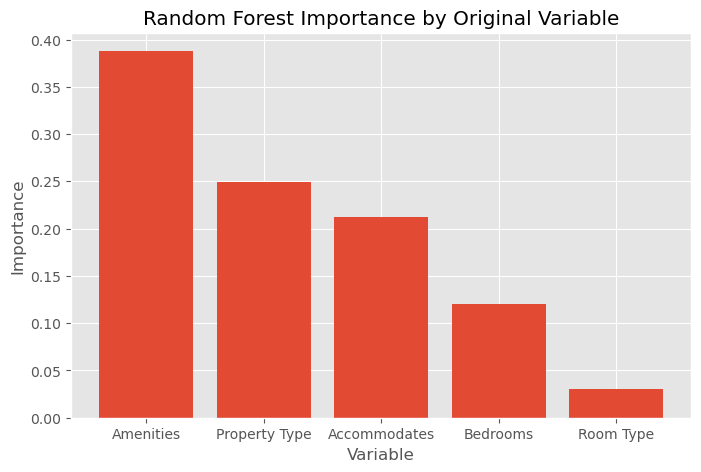

In [31]:
plt.figure(figsize=(8,5))

plt.bar(
    rf_summary["Variable"],
    rf_summary["Importance"]
)

plt.title("Random Forest Importance by Original Variable")
plt.xlabel("Variable")
plt.ylabel("Importance")

plt.show()

In [32]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [34]:
perm_importance = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Importance": perm.importances_mean
    })
    .sort_values("Importance", ascending=False)
)

perm_importance

,Feature,Importance
0,accommodates,0.158438
1,bedrooms,0.150548
2,amenities_count,0.077807
90,property_type_Room in hotel,0.011816
42,property_type_Private room in apartment,0.005249
...,...,...
33,property_type_Entire villa,-0.001495
103,property_type_Shared room in condominium,-0.001509
27,property_type_Entire loft,-0.002104
128,room_type_Shared room,-0.002437


In [35]:
perm_summary = pd.DataFrame({
    "Variable": [
        "Amenities",
        "Accommodates",
        "Bedrooms",
        "Property Type",
        "Room Type"
    ],
    "Importance": [
        perm_importance.loc[
            perm_importance["Feature"] == "amenities_count",
            "Importance"
        ].sum(),

        perm_importance.loc[
            perm_importance["Feature"] == "accommodates",
            "Importance"
        ].sum(),

        perm_importance.loc[
            perm_importance["Feature"] == "bedrooms",
            "Importance"
        ].sum(),

        perm_importance.loc[
            perm_importance["Feature"].str.startswith("property_type_"),
            "Importance"
        ].sum(),

        perm_importance.loc[
            perm_importance["Feature"].str.startswith("room_type_"),
            "Importance"
        ].sum()
    ]
})

perm_summary = perm_summary.sort_values(
    "Importance",
    ascending=False
)

perm_summary

,Variable,Importance
1,Accommodates,0.158438
2,Bedrooms,0.150548
0,Amenities,0.077807
3,Property Type,0.016903
4,Room Type,0.002325


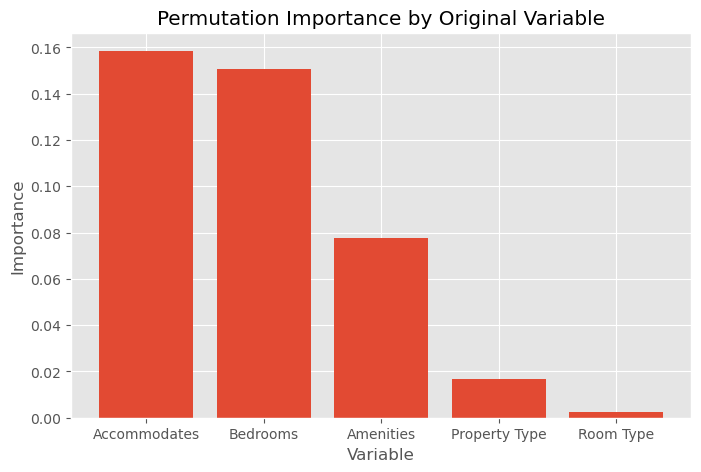

In [36]:
plt.figure(figsize=(8,5))

plt.bar(
    perm_summary["Variable"],
    perm_summary["Importance"]
)

plt.title("Permutation Importance by Original Variable")
plt.xlabel("Variable")
plt.ylabel("Importance")

plt.show()

| Variable | Business Relevance | EDA Observation | Random Forest Importance | Permutation Importance |
|---|---|---|---:|---:|
| Amenities | High | Strong | 0.388 | 0.078 |
| Property Type | High | Moderate | 0.250 | 0.017 |
| Accommodates | High | Weak–Moderate | 0.212 | 0.158 |
| Bedrooms | High | Moderate | 0.120 | 0.151 |
| Room Type | High | Moderate | 0.031 | 0.002 |

## Weight Determination Methodology

The final weights for the ListingIQ components are derived by combining three complementary sources of evidence rather than relying on a single importance metric.

### 1. Permutation Importance (60%)

Permutation Importance measures the decrease in predictive performance when a feature is randomly shuffled on unseen test data. Since it evaluates feature importance using out-of-sample observations, it provides the most reliable estimate of a variable's predictive contribution and therefore receives the highest weighting.

### 2. Random Forest Feature Importance (30%)

Random Forest Feature Importance measures the contribution of each variable during model training. While it provides valuable insights into how the model utilizes different features, it may overestimate variables with high cardinality or correlated predictors. Consequently, it is assigned a lower weight than Permutation Importance.

### 3. Exploratory Data Analysis (10%)

Exploratory Data Analysis contributes domain knowledge and statistical validation obtained during the feature evaluation stage. Since these assessments involve qualitative interpretation, they are incorporated with a relatively small influence to complement the model-driven importance measures.

The final importance score for each variable is computed as:

Final Score = 0.60 × (Permutation Importance)
            + 0.30 × (Random Forest Importance)
            + 0.10 × (Normalized EDA Score)

Finally, the resulting scores are normalized so that the component weights sum to 100%.

In [37]:
eda_scores = pd.DataFrame({
    "Variable": [
        "Amenities",
        "Property Type",
        "Room Type",
        "Accommodates",
        "Bedrooms"
    ],
    "EDA_Score": [
        1.0,   # Strong
        0.6,   # Moderate
        0.6,   # Moderate
        0.4,   # Weak-Moderate
        0.6    # Moderate
    ]
})

In [38]:
eda_scores["EDA_Normalized"] = (
    eda_scores["EDA_Score"] /
    eda_scores["EDA_Score"].sum()
)

eda_scores

,Variable,EDA_Score,EDA_Normalized
0,Amenities,1.0,0.3125
1,Property Type,0.6,0.1875
2,Room Type,0.6,0.1875
3,Accommodates,0.4,0.1250
4,Bedrooms,0.6,0.1875


In [39]:
weights = (
    rf_summary
    .merge(
        perm_summary,
        on="Variable",
        suffixes=("_RF", "_Permutation")
    )
    .merge(
        eda_scores[["Variable", "EDA_Normalized"]],
        on="Variable"
    )
)

weights

,Variable,Importance_RF,Importance_Permutation,EDA_Normalized
0,Amenities,0.387798,0.077807,0.3125
1,Property Type,0.249725,0.016903,0.1875
2,Accommodates,0.212011,0.158438,0.1250
3,Bedrooms,0.119952,0.150548,0.1875
4,Room Type,0.030513,0.002325,0.1875


In [40]:
weights["Composite_Score"] = (
    0.30 * weights["Importance_RF"] +
    0.60 * weights["Importance_Permutation"] +
    0.10 * weights["EDA_Normalized"]
)

In [41]:
weights["Final_Weight"] = (
    weights["Composite_Score"] /
    weights["Composite_Score"].sum()
) * 100

weights = weights.sort_values(
    "Final_Weight",
    ascending=False
)

weights

,Variable,Importance_RF,Importance_Permutation,EDA_Normalized,Composite_Score,Final_Weight
0,Amenities,0.387798,0.077807,0.3125,0.194274,30.184889
2,Accommodates,0.212011,0.158438,0.1250,0.171166,26.594624
3,Bedrooms,0.119952,0.150548,0.1875,0.145064,22.539079
1,Property Type,0.249725,0.016903,0.1875,0.103809,16.129152
4,Room Type,0.030513,0.002325,0.1875,0.029299,4.552257


| Variable          | Final Weight |
| ----------------- | -----------: |
| **Amenities**     |   **30.18%** |
| **Accommodates**  |   **26.59%** |
| **Bedrooms**      |   **22.54%** |
| **Property Type** |   **16.13%** |
| **Room Type**     |    **4.55%** |
| **Total**         |  **100.00%** |


### Step 1: Normalize Each Variable

| Variable      | Normalization   |
| ------------- | --------------- |
| Amenities     | Min-Max Scaling |
| Accommodates  | Min-Max Scaling |
| Bedrooms      | Min-Max Scaling |
| Property Type | Quality Mapping |
| Room Type     | Quality Mapping |


In [42]:
min_amenities = listings_fe["amenities_count"].min()
max_amenities = listings_fe["amenities_count"].max()

listings_fe["amenities_score"] = (
    (listings_fe["amenities_count"] - min_amenities) /
    (max_amenities - min_amenities)
)

In [43]:
min_acc = listings_fe["accommodates"].min()
max_acc = listings_fe["accommodates"].max()

listings_fe["accommodates_score"] = (
    (listings_fe["accommodates"] - min_acc) /
    (max_acc - min_acc)
)

In [44]:
min_bed = listings_fe["bedrooms"].min()
max_bed = listings_fe["bedrooms"].max()

listings_fe["bedrooms_score"] = (
    (listings_fe["bedrooms"] - min_bed) /
    (max_bed - min_bed)
)

In [45]:
min_bed = listings_fe["bedrooms"].min()
max_bed = listings_fe["bedrooms"].max()

listings_fe["bedrooms_score"] = (
    (listings_fe["bedrooms"] - min_bed) /
    (max_bed - min_bed)
)

In [46]:
property_scores = (
    listings_fe
    .groupby("property_type")["review_scores_rating"]
    .mean()
    .sort_values()
)

property_scores

property_type
Shared room in casa particular    55.500000
Private room in dome house        59.333333
Campsite                          67.333333
Private room in castle            67.333333
Shared room in yurt               68.250000
                                    ...    
Shared room in parking space            NaN
Shared room in pension                  NaN
Shared room in tent                     NaN
Tipi                                    NaN
Windmill                                NaN
Name: review_scores_rating, Length: 144, dtype: float64

In [47]:
room_scores = (
    listings_fe
    .groupby("room_type")["review_scores_rating"]
    .mean()
    .sort_values()
)

room_scores

room_type
Hotel room      90.666578
Shared room     91.240558
Private room    92.836126
Entire place    93.735500
Name: review_scores_rating, dtype: float64

In [48]:
property_scores = (
    (property_scores - property_scores.min()) /
    (property_scores.max() - property_scores.min())
)

property_scores

property_type
Shared room in casa particular    0.000000
Private room in dome house        0.086142
Campsite                          0.265918
Private room in castle            0.265918
Shared room in yurt               0.286517
                                    ...   
Shared room in parking space           NaN
Shared room in pension                 NaN
Shared room in tent                    NaN
Tipi                                   NaN
Windmill                               NaN
Name: review_scores_rating, Length: 144, dtype: float64

In [49]:
room_scores = (
    (room_scores - room_scores.min()) /
    (room_scores.max() - room_scores.min())
)

room_scores

room_type
Hotel room      0.000000
Shared room     0.187030
Private room    0.706942
Entire place    1.000000
Name: review_scores_rating, dtype: float64

In [50]:
listings_fe["property_type_score"] = (
    listings_fe["property_type"].map(property_scores)
)

listings_fe["room_type_score"] = (
    listings_fe["room_type"].map(room_scores)
)

Calculate ListingIQ

| Variable      | Weight |
| ------------- | -----: |
| Amenities     | 30.18% |
| Accommodates  | 26.59% |
| Bedrooms      | 22.54% |
| Property Type | 16.13% |
| Room Type     |  4.55% |


In [51]:
listings_fe["ListingIQ"] = (
    0.3018 * listings_fe["amenities_score"] +
    0.2659 * listings_fe["accommodates_score"] +
    0.2254 * listings_fe["bedrooms_score"] +
    0.1613 * listings_fe["property_type_score"] +
    0.0455 * listings_fe["room_type_score"]
) * 100

In [52]:
listings_fe["ListingIQ"].describe()

count    250240.000000
mean         28.874451
std           6.329156
min           3.980056
25%          24.184411
50%          28.031367
75%          32.336119
max          79.351570
Name: ListingIQ, dtype: float64

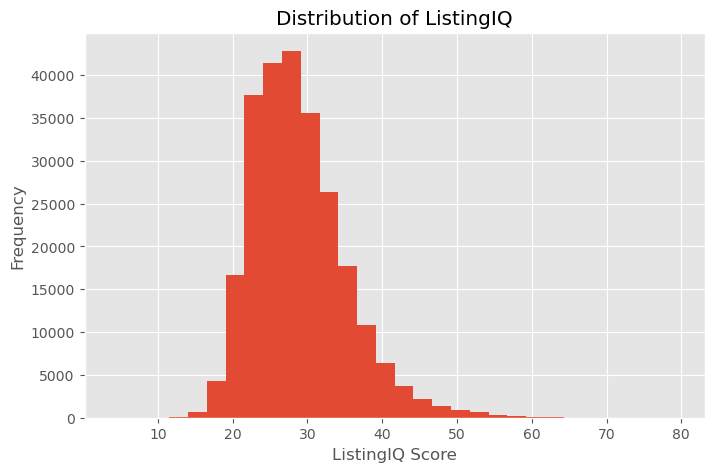

In [53]:
plt.figure(figsize=(8,5))

plt.hist(
    listings_fe["ListingIQ"],
    bins=30
)

plt.title("Distribution of ListingIQ")
plt.xlabel("ListingIQ Score")
plt.ylabel("Frequency")

plt.show()

In [54]:
listings_fe.groupby(
    pd.qcut(listings_fe["ListingIQ"], 5)
)["review_scores_rating"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
ListingIQ,,,,
"(3.979, 23.506]",24579,91.356849,96.0,13.224384
"(23.506, 26.558]",31121,93.137656,96.0,10.730252
"(26.558, 29.543]",35146,93.738690,96.0,9.378050
"(29.543, 33.528]",38111,94.111438,96.0,8.742261
"(33.528, 79.352]",39547,94.643437,97.0,8.163921


## ListingIQ Validation

The ListingIQ score demonstrates a clear positive relationship with guest satisfaction. As ListingIQ increases, the average guest review rating consistently rises across all quintiles, indicating that the selected variables collectively capture meaningful aspects of listing quality.

Listings in the highest ListingIQ quintile achieve the highest average guest ratings while also exhibiting lower variability in review scores, suggesting a more consistent guest experience. Conversely, listings in the lowest quintile receive the lowest average ratings and show greater variation in guest satisfaction.

These results validate the effectiveness of the ListingIQ framework and support its use as a composite indicator of listing quality.

In [55]:
listings_fe.to_csv("ListingIQ_Output.csv", index=False)